In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [ ]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_10.0/DN_FLUXDRIVEN_ITG_TEST";
data_arrays = reader.fetch_phi2D_data(directory_path, dataset = "Phithphi", dimensions = ["phi", "zeta", "theta"]);

Found 1201 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Finished compiling data from all files in the directory.
<xarray.DataArray 'Phithphi' (phi: 65, theta: 257)> Size: 134kB
array([[-1.69340050e-07, -7.74746278e-07, -1.40358513e-06, ...,
        -8.79502305e-07, -2.22766309e-07, -1.69340050e-07],
       [-3.36029336e-07, -7.09923832e-08, -5.44159376e-07, ...,
        -1.58080098e-06, -1.07307982e-06, -3.36029336e-07],
       [-1.25486933e-06, -4.94907805e-07, -3.31923679e-08, ...,
        -1.26280218e-06, -1.60306516e-06, -1.25486933e-06],
       ...,
       [-1.44774434e-06, -8.24235825e-07,  3.41684192e-07, ...,
        -5.06945022e-07, -1.19066170e-06, -1.44774434e-06],
       [-9.96984599e-07, -1.46444350e-06, -1.09286373e-06, ...,
        -1.64609542e-07, -3.19204074e-07, -9.96984599e-07],
       [-1.69340050e-07, -7.74746278e-07, -1.40358513e-06, ...,
        -8.79502305e-07, -2.22766309e-07, -1.69340050e-07]],
      shape=(65, 257))
Dimens

In [29]:
def extract_fourier_modes(phi2D_list, modes_list):

	time_series = xr.concat(phi2D_list, dim = "time");
	n_theta = len(time_series.theta);
	n_phi = len(time_series.phi);
	# For a theta transform, we normalise by 1/n_theta. For a phi transform, we similarly normalise by 1/n_phi.
	# When transforming in 2D, we normalise by the product of both mesh lengths.
	mesh_normalisation = n_theta * n_phi;

	amplitudes = {};
	fourier_sum = np.fft.fft2(time_series.values) / mesh_normalisation;

	for (m, n) in modes_list:

		amplitudes[(m, n)] = np.abs(fourier_sum[:, m, n]);

	return amplitudes;


In [50]:
def plot_saturation_diagnostic(amplitudes, dt_diag):

	fig, ax = plt.subplots(figsize=(10, 5));

	n_snapshots = len(next(iter(amplitudes.values())));
	times = np.arange(n_snapshots) * dt_diag;

	for (m, n), amp in amplitudes.items():
		ax.semilogy(times, amp, label=f"(m,n) = {m},{n}");

	ax.set_xlabel("time");
	ax.set_ylabel(r"$|{\Phi}_{mn}|$");
	ax.set_title(r"$|{\Phi}_{mn}|$ evolution, radially-averaged")
	ax.legend(fontsize = 8, loc="lower right");
	ax.grid(True, which = "both", alpha = 0.3);

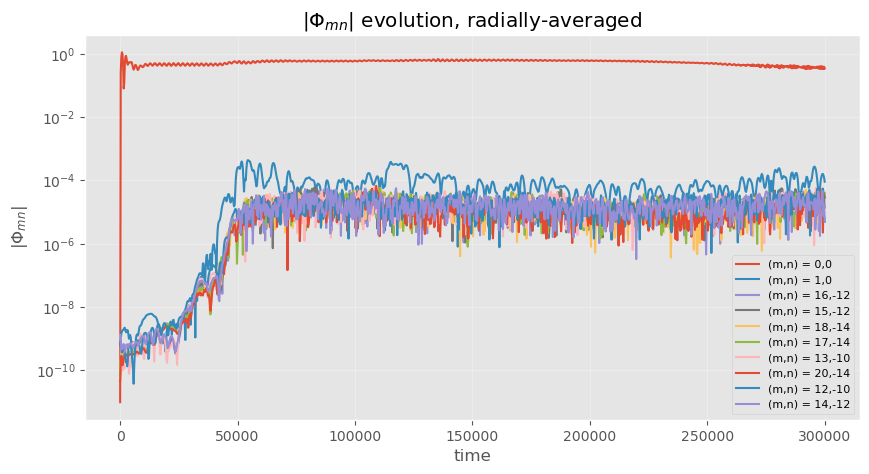

In [51]:
modes = [(0, 0), (1, 0), (16, -12), (15, -12), (18, -14), (17, -14), (13, -10), (20, -14), (12, -10), (14, -12)];
mode_amplitudes = extract_fourier_modes(data_arrays, modes);
plot_saturation_diagnostic(mode_amplitudes, dt_diag = 250);